# L602 — Hyperparameter Tuning with Optuna

**Frameworks:** DEAP and Optuna  
**Problem:** N-Queens  
**Course:** CS 5660 — Advanced Artificial Intelligence

This notebook extends the N-Queens evolutionary-algorithm example by replacing
exhaustive grid search and uninformed random sampling with **Optuna's adaptive
Tree-structured Parzen Estimator (TPE)** search.

## Learning objectives

By the end of this notebook, you should be able to:

1. express an evolutionary algorithm's hyperparameters as an Optuna search space;
2. define a stochastic objective using repeated runs;
3. maximize a utility that balances solution quality, success, and efficiency;
4. inspect optimization history and parameter importance; and
5. validate the selected configuration on seeds that were not used during tuning.


## 1. Setup

The notebook uses `ea.py` and `utils.py` from the same directory. If Optuna is
not installed in the active Jupyter kernel, uncomment and run the installation
command once, then restart the kernel if Jupyter requests it.


In [1]:
# Uncomment only if Optuna is not installed in this Jupyter environment.
# %pip install optuna

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from ea import run_n_queens_ea
from utils import draw_board

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("DEAP helpers and Optuna are ready.")

DEAP helpers and Optuna are ready.


## Optuna: A hyperparameter optimization framework
Optuna is an automatic hyperparameter optimization software framework, particularly designed for machine learning. It features an imperative, define-by-run style user API. Thanks to our define-by-run API, the code written with Optuna enjoys high modularity, and the user of Optuna can dynamically construct the search spaces for the hyperparameters.


We use the terms study and trial as follows:

- Study: optimization based on an objective function

- Trial: a single execution of the objective function

For more information visit the following link: [https://optuna.readthedocs.io/en/stable/]


```python

# Define an objective function to be min/max.
def objective(trial):
    # Invoke suggest methods of a Trial object to generate hyperparameters.
    # return  An objective value linked with the Trial object.

study = optuna.create_study()  # Create a new study.
study.optimize(objective, n_trials=100)  # Invoke optimization of the objective function.

```


## 2. Experiment design

The evolutionary algorithm is stochastic: the same configuration can produce
different results on different runs. Consequently, one Optuna trial evaluates
its configuration on several shared random seeds and returns the **mean utility**.

Using the same search seeds for every trial makes comparisons less noisy. Later,
the winning configuration is evaluated on a separate set of validation seeds.


In [2]:
N_QUEENS = 8
MAX_FITNESS_EVALUATIONS = 10_000

# Small during search for speed; larger during final validation.
SEARCH_REPEATS = 3
VALIDATION_REPEATS = 10
SEARCH_SEED = 42
VALIDATION_SEED_OFFSET = 10_000

BASELINE = {
    "population_size": 100,
    "crossover_probability": 1.0,
    "mutation_probability": 0.8,
    "tournament_size": 5,
}

# The weights are nonnegative and sum to one.
UTILITY_WEIGHTS = {
    "quality": 0.75,
    "success": 0.20,
    "efficiency": 0.05,
}

assert np.isclose(sum(UTILITY_WEIGHTS.values()), 1.0)

### Utility

For one run, define

$$
\text{quality}=\frac{\text{best fitness}}{\binom{N}{2}}, \qquad
\text{success}=\mathbb{1}\!\left[\text{best fitness}=\binom{N}{2}\right],
$$

and

$$
\text{efficiency}=1-\frac{\text{fitness evaluations used}}
{\text{maximum fitness evaluations}}.
$$

The scalar objective maximized by Optuna is

$$
U=0.75(\text{quality})+0.20(\text{success})+0.05(\text{efficiency}).
$$

All components and the resulting utility lie in $[0,1]$.


In [3]:
def utility_components(result, *, n_queens, max_fitness_evaluations):
    """Convert one EA result into normalized utility components."""
    optimum = n_queens * (n_queens - 1) // 2
    quality = result["best_fitness"] / optimum
    success = float(result["success"])
    efficiency = max(
        0.0,
        1.0 - result["evaluations"] / max_fitness_evaluations,
    )
    utility = (
        UTILITY_WEIGHTS["quality"] * quality
        + UTILITY_WEIGHTS["success"] * success
        + UTILITY_WEIGHTS["efficiency"] * efficiency
    )
    return {
        "quality": quality,
        "success": success,
        "efficiency": efficiency,
        "utility": utility,
    }


def evaluate_configuration(
    params,
    *,
    repeats,
    seed_offset,
    method,
    configuration_id,
):
    """Evaluate one configuration repeatedly and return tidy result rows."""
    rows = []

    for repeat in range(repeats):
        run_seed = seed_offset + repeat
        started = perf_counter()
        result = run_n_queens_ea(
            n_queens=N_QUEENS,
            max_fitness_evaluations=MAX_FITNESS_EVALUATIONS,
            seed=run_seed,
            **params,
        )
        elapsed = perf_counter() - started
        components = utility_components(
            result,
            n_queens=N_QUEENS,
            max_fitness_evaluations=MAX_FITNESS_EVALUATIONS,
        )

        rows.append(
            {
                "method": method,
                "configuration_id": configuration_id,
                "repeat": repeat + 1,
                "seed": run_seed,
                **params,
                "best_fitness": result["best_fitness"],
                "evaluations": result["evaluations"],
                "elapsed_seconds": elapsed,
                **components,
            }
        )

    return rows

## 3. Establish a baseline

Before tuning, evaluate the configuration used in the original notebook. These
results are descriptive; the final comparison later uses held-out seeds.


In [4]:
baseline_search_rows = evaluate_configuration(
    BASELINE,
    repeats=SEARCH_REPEATS,
    seed_offset=SEARCH_SEED,
    method="Baseline",
    configuration_id=0,
)

baseline_search_results = pd.DataFrame(baseline_search_rows)
baseline_search_results[
    [
        "repeat",
        "seed",
        "best_fitness",
        "evaluations",
        "quality",
        "success",
        "efficiency",
        "utility",
    ]
].round(4)

,repeat,seed,best_fitness,evaluations,quality,success,efficiency,utility
0,1,42,28,444,1.0,1.0,0.9556,0.9978
1,2,43,28,198,1.0,1.0,0.9802,0.9990
2,3,44,28,100,1.0,1.0,0.9900,0.9995


## 4. Define the Optuna objective

Each Optuna trial proposes one configuration:

| Hyperparameter | Search range |
|---|---:|
| Population size | 40 to 120, step 20 |
| Crossover probability | 0.60 to 1.00, step 0.05 |
| Mutation probability | 0.10 to 0.80, step 0.05 |
| Tournament size | 2 to 6 |

`trial.suggest_int` and `trial.suggest_float` define the search space. After each
repeat, the running mean is reported so Optuna may prune configurations that are
unlikely to perform well.


In [5]:
import optuna
import pandas as pd

OPTUNA_PARAMETER_SPACE = {
    "population_size": [40, 80, 120],
    "crossover_probability": [0.60, 0.80, 1.00],
    "mutation_probability": [0.10, 0.40, 0.80],
    "tournament_size": [2, 4, 6],
}

# Stores the individual repeated runs from every trial
all_rows = []


def objective(trial):
    """Return the mean utility for one Optuna configuration."""

    params = {
        parameter: trial.suggest_categorical(parameter, values)
        for parameter, values in OPTUNA_PARAMETER_SPACE.items()
    }

    rows = evaluate_configuration(
        params,
        repeats=SEARCH_REPEATS,
        seed_offset=SEARCH_SEED,
        method="Optuna",
        configuration_id=trial.number + 1,
    )

    all_rows.extend(rows)

    mean_utility = sum(row["utility"] for row in rows) / len(rows)

    return mean_utility

In [8]:
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=10,
)

In [9]:
print("Best utility:", round(study.best_value, 4))
print("Best parameters:", study.best_params)

optuna_results = pd.DataFrame(all_rows)
optuna_results

Best utility: 0.9995
Best parameters: {'population_size': 40, 'crossover_probability': 1.0, 'mutation_probability': 0.8, 'tournament_size': 6}


,method,configuration_id,repeat,seed,population_size,crossover_probability,mutation_probability,tournament_size,best_fitness,evaluations,elapsed_seconds,quality,success,efficiency,utility
0,Optuna,1,1,42,80,0.6,0.4,6,28,145,0.004317,1.0,1.0,0.9855,0.999275
1,Optuna,1,2,43,80,0.6,0.4,6,28,251,0.007418,1.0,1.0,0.9749,0.998745
2,Optuna,1,3,44,80,0.6,0.4,6,28,80,0.000543,1.0,1.0,0.9920,0.999600
3,Optuna,2,1,42,40,1.0,0.8,6,28,50,0.000733,1.0,1.0,0.9950,0.999750
4,Optuna,2,2,43,40,1.0,0.8,6,28,178,0.003563,1.0,1.0,0.9822,0.999110
5,Optuna,2,3,44,40,1.0,0.8,6,28,60,0.000907,1.0,1.0,0.9940,0.999700
6,Optuna,3,1,42,80,0.8,0.1,4,28,8211,0.269953,1.0,1.0,0.1789,0.958945
7,Optuna,3,2,43,80,0.8,0.1,4,28,287,0.008455,1.0,1.0,0.9713,0.998565
8,Optuna,3,3,44,80,0.8,0.1,4,28,80,0.000556,1.0,1.0,0.9920,0.999600
9,Optuna,1,1,42,80,0.6,0.4,6,28,145,0.004049,1.0,1.0,0.9855,0.999275


In [10]:
from optuna.visualization import (
    plot_contour,
    plot_intermediate_values,
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
    plot_rank,
    plot_slice,
    plot_timeline,
)

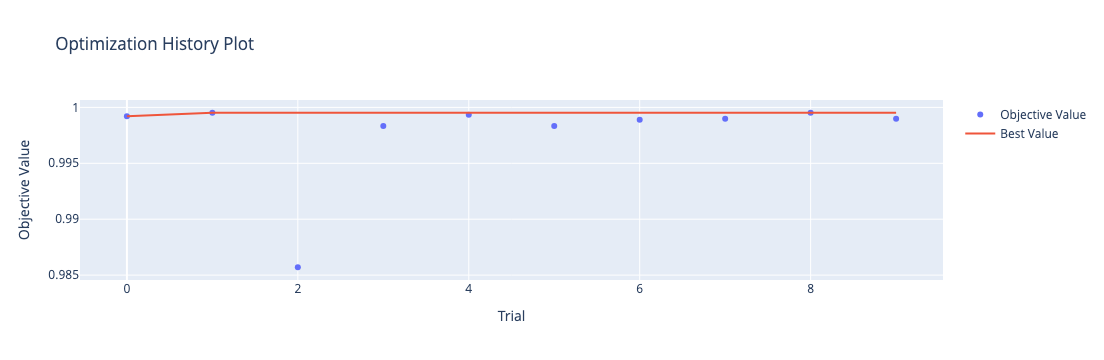

In [11]:
# Shows each trial's utility and the best value found so far
plot_optimization_history(study).show()

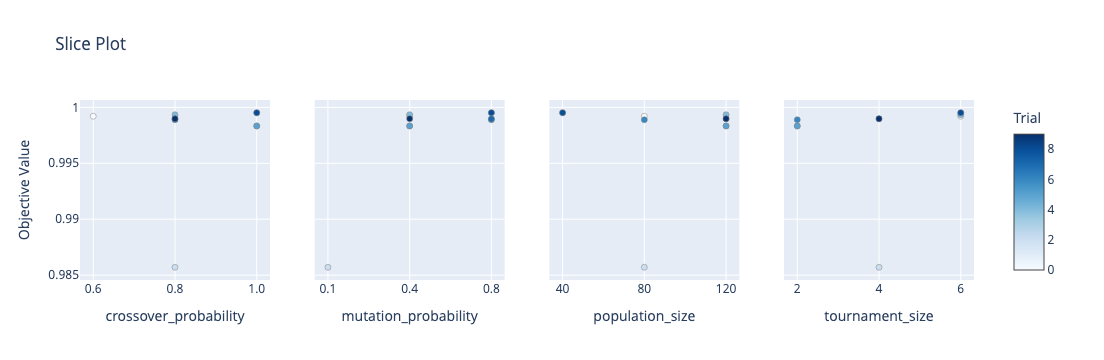

In [12]:
# Shows how each parameter relates to utility
plot_slice(study).show()

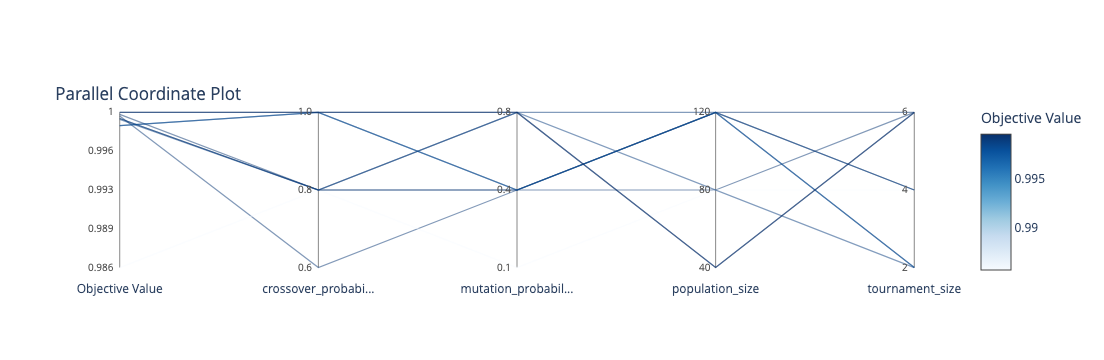

In [13]:
# Shows all parameter combinations together
plot_parallel_coordinate(study).show()

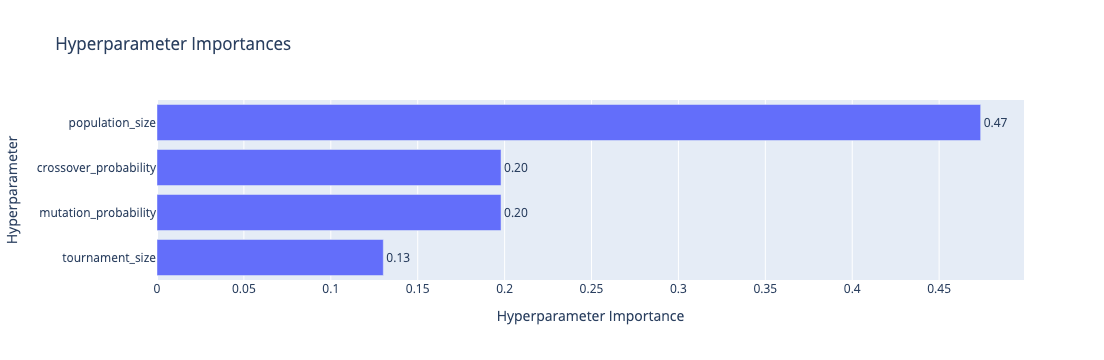

In [14]:
plot_param_importances(study).show()

In [15]:
# Stores every repeated EA run from every Optuna trial
all_rows = []


def objective(trial):
    """Evaluate one range-based Optuna configuration."""

    params = {
        "population_size": trial.suggest_int(
            "population_size",
            low=40,
            high=200,
            step=20,
        ),
        "crossover_probability": trial.suggest_float(
            "crossover_probability",
            low=0.70,
            high=1.00,
            step=0.05,
        ),
        "mutation_probability": trial.suggest_float(
            "mutation_probability",
            low=0.6,
            high=1.0,
            step=0.05,
        ),
        "tournament_size": trial.suggest_int(
            "tournament_size",
            low=2,
            high=10,
        ),
    }

    rows = evaluate_configuration(
        params,
        repeats=SEARCH_REPEATS,
        seed_offset=SEARCH_SEED,
        method="Optuna Range",
        configuration_id=trial.number + 1,
    )

    all_rows.extend(rows)

    results = pd.DataFrame(rows)

    # Save extra trial information for analysis
    trial.set_user_attr(
        "mean_quality",
        float(results["quality"].mean()),
    )
    trial.set_user_attr(
        "success_rate",
        float(results["success"].mean()),
    )
    trial.set_user_attr(
        "mean_evaluations",
        float(results["evaluations"].mean()),
    )
    trial.set_user_attr(
        "mean_elapsed_seconds",
        float(results["elapsed_seconds"].mean()),
    )

    return float(results["utility"].mean())

## 5. Run the Optuna study

The TPE sampler learns from completed trials and increasingly proposes values
associated with stronger results. The sampler seed makes the proposal sequence
reproducible.

This notebook uses `n_jobs=1` because the supplied EA seeds Python's global
random-number generator. Threaded trials could interfere with one another.


In [16]:
sampler = optuna.samplers.TPESampler(seed=SEARCH_SEED)

study = optuna.create_study(
    study_name="n_queens_range_search",
    direction="maximize",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    n_jobs=1,
    show_progress_bar=True,
)

  0%|          | 0/30 [00:00<?, ?it/s]

In [17]:
print(f"Best mean utility: {study.best_value:.4f}")
print("Best parameters:")

for parameter, value in study.best_params.items():
    print(f"  {parameter}: {value}")

Best mean utility: 0.9997
Best parameters:
  population_size: 40
  crossover_probability: 1.0
  mutation_probability: 1.0
  tournament_size: 9


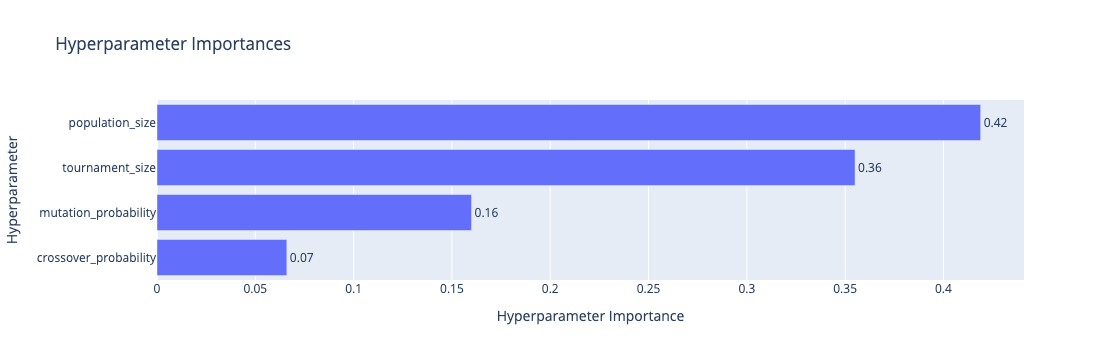

In [18]:
plot_param_importances(study).show()